# Loan Approval Prediction with Random Forest Model

#### Project Purpose:
To create a full machine learning project from scratch to deployment.

#### Business Case:
To create a model that accurately predicts loan approval and automates the approval process.

#### Goal:
To accurately predict loan approvals without falsely approving too many loans that should be denied (minimize false positives).

#### Deliverable:
A web app that end users can utilize to predict loan approvals with configurable credit score guideline.

#### Notes:
- Since the `Credit_History` variable is checking whether the applicant's credit history meets certain guidelines, I implemented a `credit_guideline` variable in `loan-app.py` that sets the preferred minimum credit score of an applicant. 
- The web app asks the user for their current credit score, and sets the `Credit_History` variable to `1` if their score is greater than or equal to the guideline score and `0` if not.
- Currently, the `credit_guideline` score is set to 670.

#### Dataset Source:
The dataset used was sourced from [Kaggle](https://www.kaggle.com/datasets/rishikeshkonapure/home-loan-approval).

#### Data Dictionary:

| Field | Description |
| :--- | :--- |
| Loan_ID | Unique Loan ID | 
| Gender | Male/Female |
| Married | Applicant married (Y/N) |
| Dependents | Number of dependents |
| Education | Applicant Education (Graduate/Not Graduate) |
| Self_Employed | Self-employed (Y/N) |
| ApplicantIncome | Applicant's income |
| CoapplicantIncome | Co-applicant income |
| LoanAmount | Loan amount in thousands of dollars |
| Loan_Amount_Term | Term of the loan in months |
| Credit_History | Credit history meets guidelines |
| Property_Area | Urban/Semi Urban/Rural |
| Loan_Status | Loan approval (Yes/No) |

---
### Install & Import Libraries

In [1]:
pip install pandas numpy scikit-learn streamlit joblib # install libraries

Note: you may need to restart the kernel to use updated packages.


In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.tree import plot_tree

import streamlit as st
import pickle

---
### Import Data

In [3]:
df = pd.read_csv('loan_train.csv') # read data
df.shape # print shape of dataset (rows, columns)

(614, 13)

In [4]:
df.head() # show first 5 rows of dataset

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


---
### Check for Class Imbalance

In [5]:
df['Loan_Status'].value_counts() # check for class imbalance

Loan_Status
Y    422
N    192
Name: count, dtype: int64

#### Conclusion:
The outcome variable is mildly imbalanced. If the dataset were moderately or severely imbalanced, it would be best to oversample the minorty class or undersample the majority class.

Some methods include:
- Randomly choosing observations to over- or under-sample
- Synthetic minority over-sampling technique (SMOTE): synthetically creates new observations based on statistics

---
### Exploratory Data Analysis (EDA)
Goal: Explore variable distributions and interactions.

#### Descriptive Statistics

In [6]:
df.describe() # descriptive statistics

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


#### Visualizations

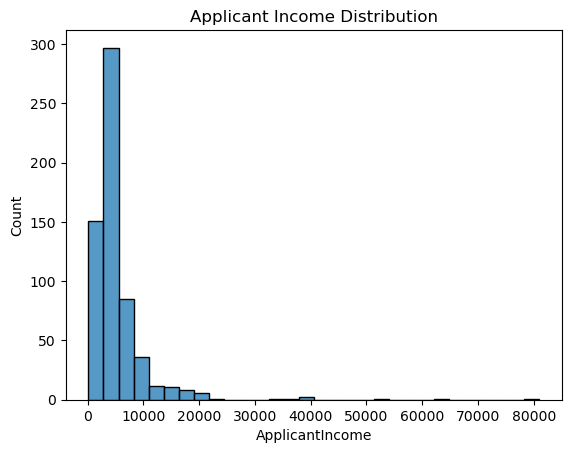

In [7]:
sns.histplot(df['ApplicantIncome'], bins=30)
plt.title("Applicant Income Distribution")
plt.show()

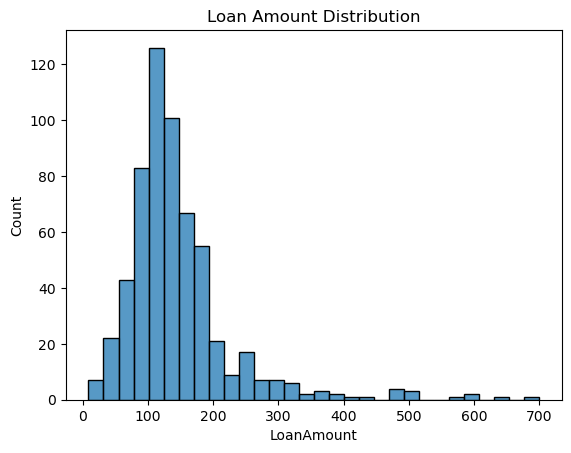

In [8]:
sns.histplot(df['LoanAmount'], bins=30)
plt.title("Loan Amount Distribution")
plt.show()

<Axes: xlabel='Loan_Amount_Term', ylabel='count'>

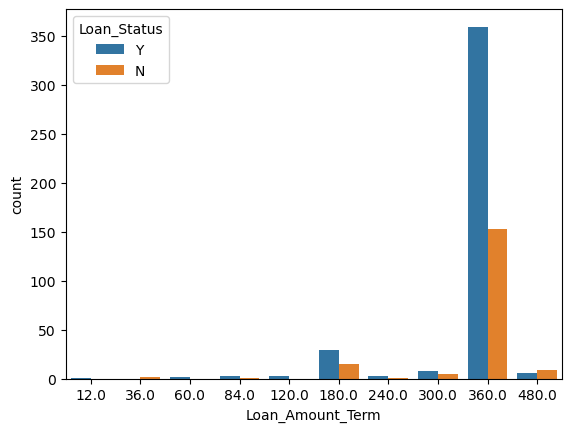

In [9]:
sns.countplot(x='Loan_Amount_Term', hue='Loan_Status', data=df)

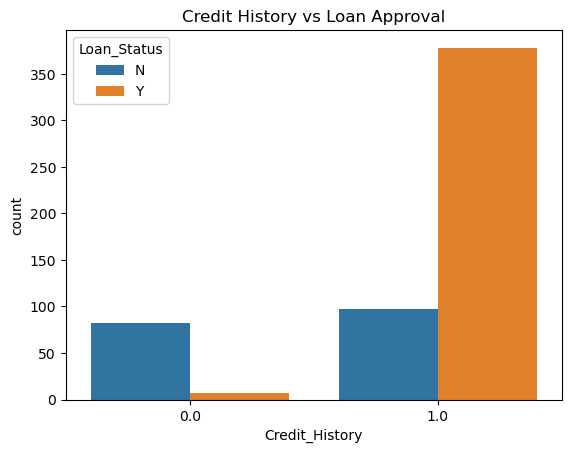

In [10]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Approval")
plt.show()

In [11]:
pd.crosstab(df['Gender'], df['Loan_Status'], margins = True)

Loan_Status,N,Y,All
Gender,,,
Female,37,75,112
Male,150,339,489
All,187,414,601


In [12]:
pd.crosstab(df['Married'], df['Loan_Status'], margins = True)

Loan_Status,N,Y,All
Married,,,
No,79,134,213
Yes,113,285,398
All,192,419,611


In [13]:
pd.crosstab(df['Education'], df['Loan_Status'], margins = True)

Loan_Status,N,Y,All
Education,,,
Graduate,140,340,480
Not Graduate,52,82,134
All,192,422,614


In [14]:
pd.crosstab(df['Self_Employed'], df['Loan_Status'], margins = True)

Loan_Status,N,Y,All
Self_Employed,,,
No,157,343,500
Yes,26,56,82
All,183,399,582


In [15]:
pd.crosstab(df['Credit_History'], df['Loan_Status'], margins = True)

Loan_Status,N,Y,All
Credit_History,,,
0.0,82,7,89
1.0,97,378,475
All,179,385,564


In [16]:
pd.crosstab(df['Property_Area'], df['Loan_Status'], margins = True)

Loan_Status,N,Y,All
Property_Area,,,
Rural,69,110,179
Semiurban,54,179,233
Urban,69,133,202
All,192,422,614


---
### Data Cleaning

In [17]:
df.drop("Loan_ID", axis=1, inplace=True) # drop loan ID column, not useful for analysis
df.head() # show first 5 rows to confirm changes

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [18]:
print(df.shape) # check shape
df.isnull().sum() # check for null values

(614, 12)


Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [19]:
df = df.dropna() # drop null values
print(df.shape) # check shape to confirm changes

(480, 12)


---
### Feature Engineering

In [20]:
df['TotalApplicantIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df # check rows and shape to confirm changes

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalApplicantIncome
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0
5,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y,9613.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,2900.0
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,4106.0
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,8312.0
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,7583.0


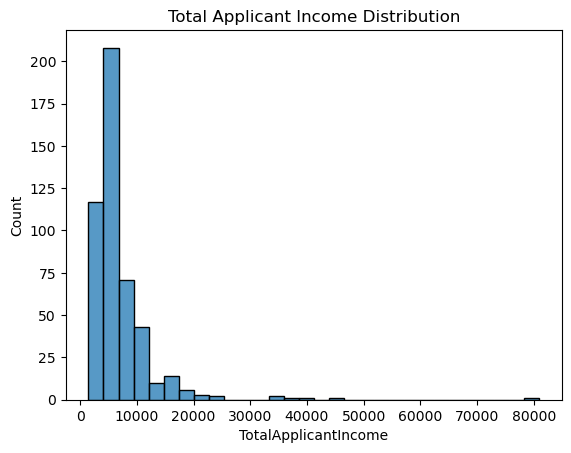

In [21]:
sns.histplot(df['TotalApplicantIncome'], bins=30)
plt.title("Total Applicant Income Distribution")
plt.show()

---
### Preparation for Random Forest Modeling

In [22]:
# convert target variable first
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [23]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'Gender',
        'Married',
        'Dependents',
        'Education',
        'Self_Employed',
        'Property_Area'
    ],
    drop_first=True
)

df_encoded.head() # check encoded data

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalApplicantIncome,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
1,4583,1508.0,128.0,360.0,1.0,0,6091.0,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,1,3000.0,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,1,4941.0,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,1,6000.0,True,False,False,False,False,False,False,False,True
5,5417,4196.0,267.0,360.0,1.0,1,9613.0,True,True,False,True,False,False,True,False,True


In [24]:
# define features and target
X = df_encoded.drop('Loan_Status', axis=1)
y = df_encoded['Loan_Status']

In [25]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

---
### Random Forest Model

In [26]:
# build random forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [27]:
y_pred = rf_model.predict(X_test) # make predictions on test data

---
### Evaluate Model

#### Accuracy
= (TP + TN) / (TP + TN + FP + FN) = (True Positives + True Negatives) / All 

What % of values were correctly predicted?

In [28]:
# accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8125


#### Precision
= TP / (TP + FP) = (True Positive) / (Predicted Positives)

What % of predicted positives are actually positive?

In [29]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.7976190476190477


#### Recall
= TP / (TP + FN) = (True Positive) / (Actual Positives)

What % of actual positives are predicted positive?

In [30]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.9852941176470589


#### F1 Score
= 2 * (Precision * Recall) / (Precision + Recall)

Balances Precision and Recall (weighted average), useful for datasets with class imbalance (observations have a large number of Actual Negatives), take false positives and negatives into account.

In [31]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.881578947368421


#### Classification Report

In [32]:
# print classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.39      0.55        28
           1       0.80      0.99      0.88        68

    accuracy                           0.81        96
   macro avg       0.86      0.69      0.72        96
weighted avg       0.83      0.81      0.78        96



### Business Context and Model Evaluation
From a business perspective, the goal of this model is to support loan approval decisions while minimizing financial risk and maintaining strong predictive coverage of eligible borrowers. In this setting, the most important concern is reducing false positives (incorrectly approving risky applicants), which makes precision a key evaluation metric.

Overall, the model performs well on the test dataset, achieving an accuracy of 81.25%, indicating that it correctly classifies approximately 4 out of every 5 loan applications.

**Precision:**

The model achieves a precision of `0.80`, meaning that when it predicts a loan approval, it is correct 80% of the time. This indicates a strong level of reliability in approved predictions, with some risk of false approvals.

**Recall:**

The model achieves a recall of `0.985`, meaning it correctly identifies nearly all actual approved applicants. This is a very strong result and indicates that the model rarely misses qualified borrowers. 

**F1 Score:**

The F1 score of `0.88` reflects a strong overall balance between precision and recall. It indicates that while the model prioritizes capturing all eligible applicants (high recall), it still maintains reasonable accuracy in its approval predictions (moderate precision).

**Accuracy:**

The overall accuracy of `81.25%` indicates solid general performance. However, accuracy alone does not fully capture model quality due to differing costs of misclassification.


#### Conclusions
The model demonstrates a strong tendency to prioritize identifying approved applicants, as reflected by the extremely high recall. This ensures that very few eligible borrowers are missed, which is beneficial from a revenue perspective.

However, the trade-off is a moderate reduction in precision, meaning some applicants may be incorrectly predicted as approved. In a real-world lending environment, this would need to be carefully managed, as false approvals carry higher financial risk than false rejections.

Overall, the model is well-suited for scenarios where maximizing loan approvals and minimizing missed opportunities is prioritized, but it may require further tuning (such as threshold adjustment or class weighting) for risk reduction.

---
### Confusion Matrix
Identifies True Positives, True Negatives, False Positives, and False Negatives based on predicted and actual values in the following format:

|         |Predicted Negative|Predicted Positive|
|----               |----    |----    |
|**Actual Negative**|**TN**  | FP     |
|**Actual Positive**| FN     |**TP**  |


                                        FP is Type I error, FN is Type II error

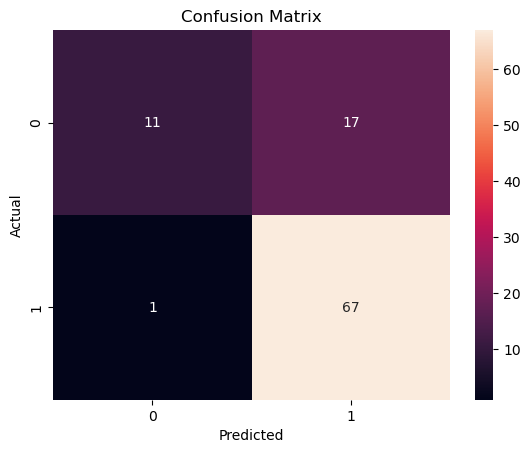

In [33]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

---
### Decision Tree

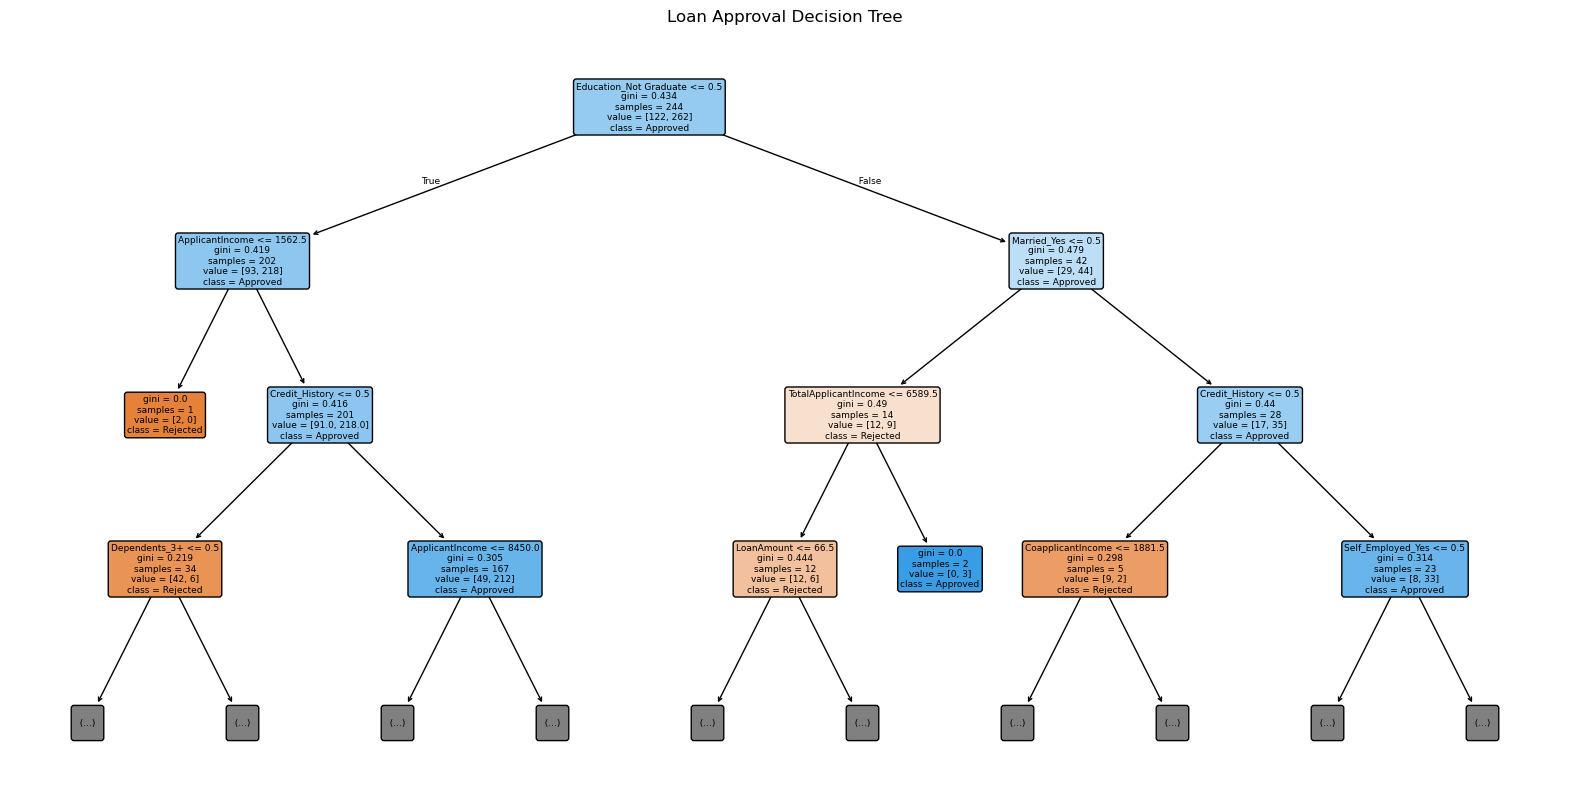

In [39]:
single_tree = rf_model.estimators_[50]

plt.figure(figsize=(20,10))

plot_tree(
    single_tree,
    feature_names=X.columns,
    class_names=["Rejected", "Approved"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Loan Approval Decision Tree")
plt.show()

---
### Feature Importance

In [35]:
# feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(10)

,Feature,Importance
4,Credit_History,0.281063
5,TotalApplicantIncome,0.146817
0,ApplicantIncome,0.134058
2,LoanAmount,0.130582
1,CoapplicantIncome,0.088088
3,Loan_Amount_Term,0.057281
13,Property_Area_Semiurban,0.029326
7,Married_Yes,0.020803
11,Education_Not Graduate,0.018792
6,Gender_Male,0.017166


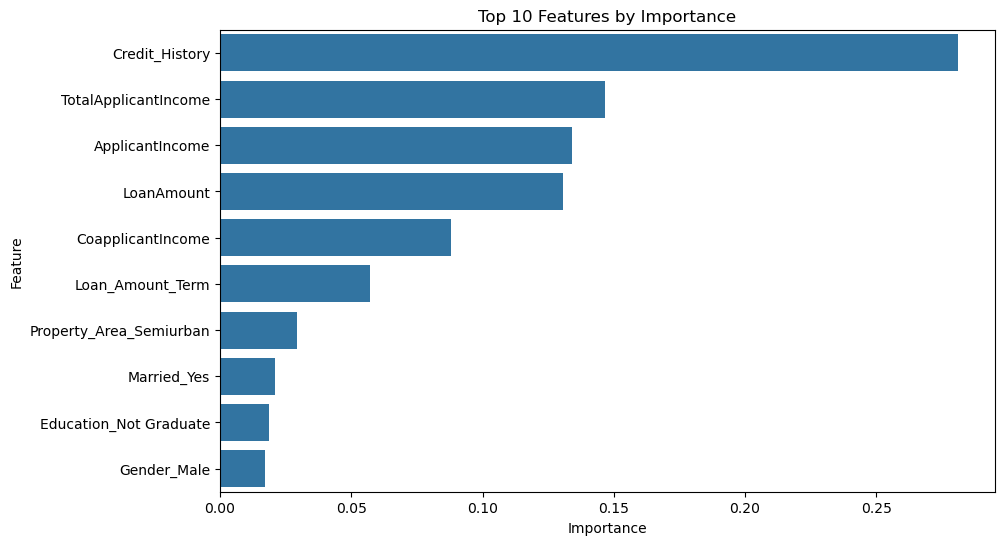

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Features by Importance")
plt.show()

---
### Transfer Model to Web App

In [37]:
# save pkl files for web app

# save trained model
with open('loan_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

# save feature columns
model_features = X.columns
with open('model_features.pkl', 'wb') as file:
    pickle.dump(model_features, file)